---

<div dir="rtl" style="text-align: right; font-size: 22px; font-weight: bold; background-color: #8b0000; padding: 15px; border-radius: 10px;">

# Practice Exercise: Company/Person NER with Transformers

</div>

**Now it's YOUR turn!**

**Task:** Named Entity Recognition for Companies and People

**Dataset:** Generated sentences with company and person names

**What you need to do:**

1. Generate Company/Person NER dataset
2. Build vocabulary and dataset class
3. Implement BiLSTM + Attention model
4. Implement Transformer model
5. Train and compare

**Hints:**

- Similar to Food NER (Week 8) but with different entities
- Use Attention mechanisms (from News Classification above)
- Follow patterns from both examples!

## Generate Company/Person NER Dataset


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.metrics import accuracy_score
from collections import Counter
from datasets import load_dataset
import random
import math
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('dark_background')
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


In [31]:
# Entity lists
companies = ['Google', 'Microsoft', 'Apple', 'Amazon', 'Facebook', 'Alaraby', 'Noon',
             'IBM', 'Intel', 'Oracle', 'Samsung', 'Sony', 'Toyota', 'Nike', 'Adidas']
people = ["Ali", "Mona", "Ahmed", "Samira", "Hassan", "Layla", "Youssuf", "Nadia",
          "Omar", "Reem", "Khalid", "Amira", "Mustafa", "Fatema", "Tariq"]

templates_ner = [
    '{person} works at {company}',
    '{company} hired {person} last month',
    '{person} is the CEO of {company}',
    'The meeting with {person} at {company} was productive',
    '{company} announced a new product by {person}',
    '{person} and {person} joined {company}',
    '{company} and {company} are competitors',
    '{person} left {company} for {company}',
]


def generate_ner_sentence():
    template = random.choice(templates_ner)
    sentence = template
    while '{person}' in sentence:
        sentence = sentence.replace('{person}', random.choice(people), 1)
    while '{company}' in sentence:
        sentence = sentence.replace('{company}', random.choice(companies), 1)
    words = sentence.lower().split()
    # Labels: 0=Other, 1=Person, 2=Company
    labels = []
    for word in words:
        if word.lower() in [p.lower() for p in people]:
            labels.append(1)
        elif word.lower() in [c.lower() for c in companies]:
            labels.append(2)
        else:
            labels.append(0)
    return words, labels


# Generate 2000 sentences
random.seed(42)
ner_sentences = []
ner_labels = []
for _ in range(2000):
    words, labels = generate_ner_sentence()
    ner_sentences.append(words)
    ner_labels.append(labels)

# Split
split1 = int(0.8 * len(ner_sentences))
split2 = int(0.9 * len(ner_sentences))
train_ner_sent = ner_sentences[:split1]
train_ner_lab = ner_labels[:split1]
val_ner_sent = ner_sentences[split1:split2]
val_ner_lab = ner_labels[split1:split2]
test_ner_sent = ner_sentences[split2:]
test_ner_lab = ner_labels[split2:]

print(f'Generated {len(ner_sentences)} NER sentences')
print(f'Train: {len(train_ner_sent)}, Val: {len(val_ner_sent)}, Test: {len(test_ner_sent)}')
print(f'\nSample: {", ".join(train_ner_sent[0])}')
print(f'Labels: {train_ner_lab[0]} (0=O, 1=Person, 2=Company)')

Generated 2000 NER sentences
Train: 1600, Val: 200, Test: 200

Sample: sony, hired, ali, last, month
Labels: [2, 0, 1, 0, 0] (0=O, 1=Person, 2=Company)


## TODO 1: Build Vocabulary and Dataset

Create vocabulary and NERDataset class for the Company/Person NER task.


In [32]:
# TODO: Build vocabulary and create dataset class

ner_vocab = {'<PAD>': 0, '<UNK>': 1}
ner_word_counts = Counter()

for sentence in train_ner_sent:
    ner_word_counts.update(sentence)

for word, count in ner_word_counts.items():
    if word not in ner_vocab:
        ner_vocab[word] = len(ner_vocab)

class NERDataset(Dataset):
    def __init__(self, sentences, labels, vocab, max_len=100):
        self.sentences = sentences
        self.labels = labels
        self.vocab = vocab
        self.max_len = int(max_len)
    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, index):
        sentence = self.sentences[index][:self.max_len]
        label = self.labels[index][:self.max_len]

        word_ids = [self.vocab.get(word, self.vocab['<UNK>']) for word in sentence]
        return torch.tensor(word_ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

def ner_collate_fn(batch):
    sentences, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in sentences])

    padded_sentences = pad_sequence(sentences, batch_first=True, padding_value=ner_vocab['<PAD>'])
    padded_labels = pad_sequence(labels, batch_first=True, padding_value=-1)

    return padded_sentences, padded_labels, lengths

train_ner_dataset = NERDataset(train_ner_sent, train_ner_lab, ner_vocab)
val_ner_dataset = NERDataset(val_ner_sent, val_ner_lab, ner_vocab)
test_ner_dataset = NERDataset(test_ner_sent, test_ner_lab, ner_vocab)

train_ner_loader = DataLoader(train_ner_dataset, batch_size=32, shuffle=True, collate_fn=ner_collate_fn)
val_ner_loader = DataLoader(val_ner_dataset, batch_size=32, shuffle=False, collate_fn=ner_collate_fn)
test_ner_loader = DataLoader(test_ner_dataset, batch_size=32, shuffle=False, collate_fn=ner_collate_fn)

print(f'NER Vocabulary size: {len(ner_vocab)}')
print(f'Train batches: {len(train_ner_loader)}')

NER Vocabulary size: 56
Train batches: 50


In [33]:
# note in here how i didn't give you the file but i uploaded it to my google drive
# so that you can download them to your colab machine
# glove_path = 'https://drive.google.com/file/d/1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q/view?usp=sharing'
import gdown

# Google Drive file ID from my link
file_id = "1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q"
url = f"https://drive.google.com/uc?id={file_id}"

output = "glove_vectors.txt"
gdown.download(url, output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q
From (redirected): https://drive.google.com/uc?id=1WTbdKo7sNTfvRim2Sxm_aSNn2sCibe1q&confirm=t&uuid=1ee66fb6-da9b-4767-a78e-46403b592a8b
To: /content/glove_vectors.txt
100%|██████████| 1.68G/1.68G [00:17<00:00, 97.6MB/s]


'glove_vectors.txt'

In [34]:
# Load pre-trained GloVe embeddings (reuse from Part 1 if available)
EMBEDDING_DIM = 100

print("Loading GloVe embeddings...")
# glove_path = 'glove.2024.wikigiga.100d\wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt'
glove_path = 'glove_vectors.txt'

# Load GloVe vectors with error handling
glove_vectors = {}
skipped = 0

with open(glove_path, 'r', encoding='utf-8') as f:
    for line_num, line in enumerate(f):
        try:
            values = line.rstrip().split(' ')
            word = values[0]
            vector = np.array(values[1:], dtype='float32')

            if len(vector) == EMBEDDING_DIM:
                glove_vectors[word] = vector
            else:
                skipped += 1
        except (ValueError, IndexError):
            skipped += 1
            continue

        if (line_num + 1) % 100000 == 0:
            print(f"  Processed {line_num + 1:,} lines...")

print(f"\nLoaded {len(glove_vectors):,} GloVe vectors")
if skipped > 0:
    print(f"Skipped {skipped:,} malformed lines")

Loading GloVe embeddings...
  Processed 100,000 lines...
  Processed 200,000 lines...
  Processed 300,000 lines...
  Processed 400,000 lines...
  Processed 500,000 lines...
  Processed 600,000 lines...
  Processed 700,000 lines...
  Processed 800,000 lines...
  Processed 900,000 lines...
  Processed 1,000,000 lines...
  Processed 1,100,000 lines...
  Processed 1,200,000 lines...

Loaded 1,291,147 GloVe vectors


## TODO 2: Implement BiLSTM + Attention for NER

Implement a BiLSTM with Attention mechanism for many-to-many NER.

**Hint:** Combine patterns from Food NER (Week 8) and News Attention (above)!


In [35]:
# TODO: Implement BiLSTM + Attention for NER (many-to-many)

# BiLSTM + Attention

class BiLSTMAttentionNER(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True,
                            num_layers=2, dropout=0.3)
        self.dropout = nn.Dropout(0.5)

        # Self-Attention layer for Many-to-Many relationships
        self.attention = nn.MultiheadAttention(embed_dim=hidden_dim * 2, num_heads=4, batch_first=True, dropout=0.3)

        # Output layer for each token
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)
        embedded = self.dropout(embedded)

        # LSTM encoding
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        output, _ = self.lstm(packed)
        output, _ = torch.nn.utils.rnn.pad_packed_sequence(output, batch_first=True)

        # Create padding mask for attention (True for padding tokens)
        max_len = x.size(1)
        key_padding_mask = torch.arange(max_len, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)

        # Apply Self-Attention
        attn_output, _ = self.attention(query=output, key=output, value=output, key_padding_mask=key_padding_mask)

        # Add residual connection and dropout
        output = self.dropout(output + attn_output)

        # Calculate logits for EVERY token
        logits = self.fc(output)
        return logits

print('BiLSTM + Attention NER model defined!')

BiLSTM + Attention NER model defined!


## TODO 3: Implement Transformer for NER

Implement a Transformer encoder for many-to-many NER.


In [36]:
# TODO: Implement Transformer for NER (many-to-many)

# Transformer

class PositionalEncoding(nn.Module):
    """Positional encoding for transformer"""

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerNER(nn.Module):
    def __init__(self, vocab_size, embedding_dim, nhead=4, num_layers=2, num_classes=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embedding_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=nhead,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.dropout = nn.Dropout(0.3)

        # Output layer to predict class for each token
        self.fc = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, lengths):
        # Create padding mask (True where there is padding)
        max_len = x.size(1)
        mask = torch.arange(max_len, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)

        embedded = self.embedding(x)
        embedded = self.pos_encoder(embedded)

        # Transformer encoding
        output = self.transformer_encoder(embedded, src_key_padding_mask=mask)

        # In NER (Many-to-Many), we DO NOT pool the outputs.
        # We apply the fully connected layer to every token's output.
        output = self.dropout(output)
        logits = self.fc(output)

        return logits


print("Transformer model defined (2 blocks, 4 attention heads)")

Transformer model defined (2 blocks, 4 attention heads)


## Train and Compare


In [37]:
def train_ner_model(model, train_loader, epochs=15, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for sentences, labels, lengths in train_loader:
            sentences, labels = sentences.to(device), labels.to(device)
            lengths = lengths.to(device)
            optimizer.zero_grad()
            predictions = model(sentences, lengths)
            predictions = predictions.view(-1, 3)
            labels = labels.view(-1)
            loss = criterion(predictions, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')
    return losses


def evaluate_ner_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for sentences, labels, lengths in test_loader:
            sentences = sentences.to(device)
            lengths = lengths.to(device)
            predictions = model(sentences, lengths)
            predictions = torch.argmax(predictions, dim=2)
            for i in range(len(sentences)):
                length = lengths[i].item()
                all_preds.extend(predictions[i, :length].cpu().numpy())
                all_labels.extend(labels[i, :length].numpy())
    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy


print('Training functions ready!')

Training functions ready!


In [38]:
# Create embedding matrix for NER
ner_embedding_matrix = np.random.randn(len(ner_vocab), 100).astype('float32') * 0.01
ner_embedding_matrix[ner_vocab['<PAD>']] = np.zeros(100)
for word, idx in ner_vocab.items():
    if word in glove_vectors:
        ner_embedding_matrix[idx] = glove_vectors[word]

# Train BiLSTM + Attention
print('='*60)
print('Training BiLSTM + Attention NER...')
print('='*60)
bilstm_attn_ner = BiLSTMAttentionNER(len(ner_vocab), 100, 128, 3)
bilstm_attn_ner.embedding.weight.data.copy_(torch.from_numpy(ner_embedding_matrix))
bilstm_losses = train_ner_model(bilstm_attn_ner, train_ner_loader, epochs=15)
bilstm_acc = evaluate_ner_model(bilstm_attn_ner, test_ner_loader)
print(f'\nBiLSTM + Attention Accuracy: {bilstm_acc:.4f}\n')

# Train Transformer
print('='*60)
print('Training Transformer NER...')
print('='*60)
transformer_ner = TransformerNER(len(ner_vocab), 100, 4, 2, 3)
transformer_ner.embedding.weight.data.copy_(torch.from_numpy(ner_embedding_matrix))
transformer_losses = train_ner_model(transformer_ner, train_ner_loader, epochs=15, lr=0.0005)
transformer_acc = evaluate_ner_model(transformer_ner, test_ner_loader)
print(f'\nTransformer Accuracy: {transformer_acc:.4f}\n')

Training BiLSTM + Attention NER...
Epoch 1/15, Loss: 0.5212
Epoch 2/15, Loss: 0.0097
Epoch 3/15, Loss: 0.0044
Epoch 4/15, Loss: 0.0030
Epoch 5/15, Loss: 0.0035
Epoch 6/15, Loss: 0.0014
Epoch 7/15, Loss: 0.0005
Epoch 8/15, Loss: 0.0003
Epoch 9/15, Loss: 0.0047
Epoch 10/15, Loss: 0.0005
Epoch 11/15, Loss: 0.0001
Epoch 12/15, Loss: 0.0045
Epoch 13/15, Loss: 0.0017
Epoch 14/15, Loss: 0.0002
Epoch 15/15, Loss: 0.0001

BiLSTM + Attention Accuracy: 1.0000

Training Transformer NER...
Epoch 1/15, Loss: 0.2059
Epoch 2/15, Loss: 0.0046
Epoch 3/15, Loss: 0.0027
Epoch 4/15, Loss: 0.0019
Epoch 5/15, Loss: 0.0015
Epoch 6/15, Loss: 0.0012
Epoch 7/15, Loss: 0.0010
Epoch 8/15, Loss: 0.0008
Epoch 9/15, Loss: 0.0007
Epoch 10/15, Loss: 0.0006
Epoch 11/15, Loss: 0.0005
Epoch 12/15, Loss: 0.0005
Epoch 13/15, Loss: 0.0004
Epoch 14/15, Loss: 0.0004
Epoch 15/15, Loss: 0.0004

Transformer Accuracy: 1.0000



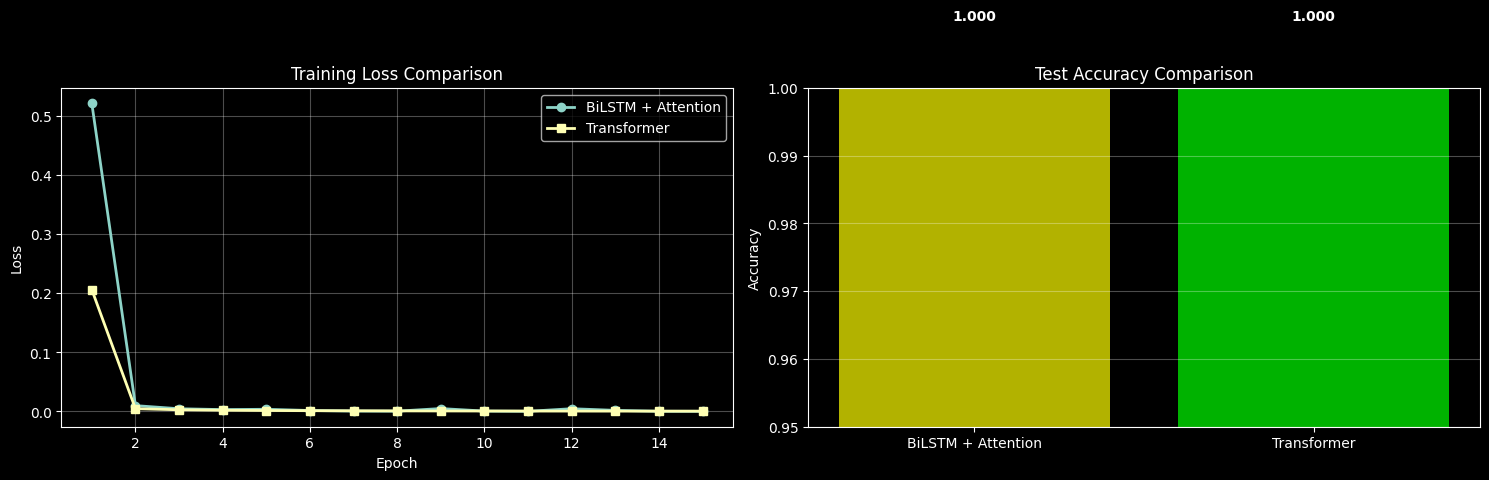

NER RESULTS
BiLSTM + Attention        Accuracy: 1.0000
Transformer               Accuracy: 1.0000


In [39]:
# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(range(1, 16), bilstm_losses, marker='o', label='BiLSTM + Attention', linewidth=2)
ax1.plot(range(1, 16), transformer_losses, marker='s', label='Transformer', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(alpha=0.3)

models = ['BiLSTM + Attention', 'Transformer']
accuracies = [bilstm_acc, transformer_acc]
colors = ['yellow', 'lime']
ax2.bar(models, accuracies, color=colors, alpha=0.7)
ax2.set_ylabel('Accuracy')
ax2.set_title('Test Accuracy Comparison')
ax2.set_ylim([min(accuracies) - 0.05, 1.0])
ax2.grid(alpha=0.3, axis='y')
for i, v in enumerate(accuracies):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('='*60)
print('NER RESULTS')
print('='*60)
for model, acc in zip(models, accuracies):
    print(f'{model:25s} Accuracy: {acc:.4f}')
print('='*60)